In [1]:
import earthkit.hydro as ekh
import numpy as np
import matplotlib.pyplot as plt

network = ekh.river_network.load("efas", "5", use_cache=False)

Cache disabled.


# Computing accumulations along rivers

There are two different types of flow accumulations: 
1. full flow accumulations (global aggregation)
2. one-step neighbor accumulations (local aggregation).

## Global aggregation

Global aggregations from sources to sinks can computed via the `ekh.upstream` submodule, and aggregations from sinks to sources can be computed using the `ekh.downstream` submodule.

Many different aggregations are possible, namely `sum`, `min`, `max`, `mean`, `var`, `std`.

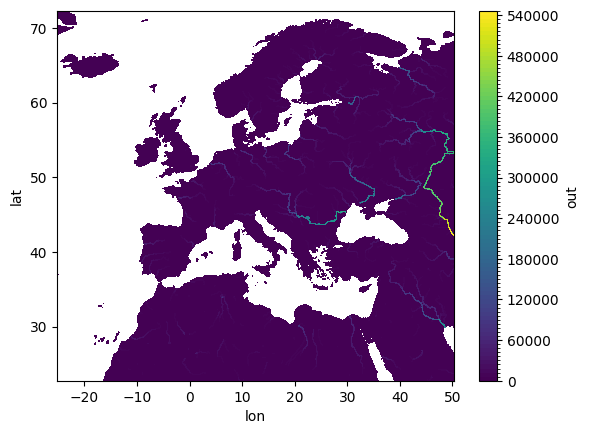

In [2]:
field = np.ones(network.shape) # or load array/xarray from file

da = ekh.upstream.sum(network, field)

da.plot.contourf(cmap="viridis", levels=100)
plt.show()

## Local aggregation

Local aggregations can be computed using the `move` submodule, and the same metrics are available.

Below we show an example using `move.downstream` to find the number of gridcells draining to each point.

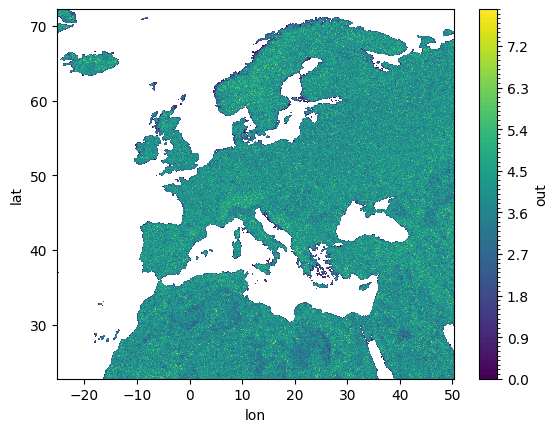

In [3]:
da = ekh.move.downstream(network, field, metric="sum")

da.plot.contourf(cmap="viridis", levels=100)
plt.show()